In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from ISLP import load_data
carseats = load_data('Carseats')
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [3]:
# Encoding the categorical Variables
carseats['ShelveLoc_enc'] = LabelEncoder().fit_transform(carseats['ShelveLoc'])
carseats['Urban_enc'] = LabelEncoder().fit_transform(carseats['Urban'])
carseats['US_enc'] = LabelEncoder().fit_transform(carseats['US'])

In [4]:
carseats.drop(['ShelveLoc', 'Urban', 'US'], axis = 1, inplace=True)
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_enc,Urban_enc,US_enc
0,9.50,138,73,11,276,120,42,17,0,1,1
1,11.22,111,48,16,260,83,65,10,1,1,1
2,10.06,113,35,10,269,80,59,12,2,1,1
3,7.40,117,100,4,466,97,55,14,2,1,1
4,4.15,141,64,3,340,128,38,13,0,1,0


In [5]:
train = carseats.loc[:299]
test = carseats.loc[300:]

In [6]:
print(f'Train : {train.shape}'); print(f'Test: {test.shape}')

Train : (300, 11)
Test: (100, 11)


In [7]:
y_train = train['Sales']
x_train = train.drop(['Sales'], axis = 1)
y_test = test['Sales']
x_test = test.drop(['Sales'], axis = 1)

In [9]:
# We are usinng a random subset of features at each step for node spliting, core point of randomness in Random Forest.
# For a regression problem, number of features at each split should be p/3 (p = total number of predictors)

In [10]:
n_features = x_train.shape[1]

In [13]:
np.ceil(n_features/3)

np.float64(4.0)

In [14]:
b = RandomForestRegressor(max_features = int(np.ceil(n_features/3)), random_state=0)  
kf = KFold(n_splits=5, shuffle=True, random_state=0)
grid = GridSearchCV(b,
                    param_grid={'n_estimators': [100,200,300,400,500,600,700,800,900,1000]},
                    scoring='neg_mean_squared_error',
                    cv = kf,
                    n_jobs = -1)
grid.fit(x_train, y_train)

,estimator,RandomForestR...andom_state=0)
,param_grid,"{'n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,800


In [15]:
grid.best_params_

{'n_estimators': 800}

In [16]:
bag = RandomForestRegressor(max_features = int(np.ceil(n_features/3)), random_state=0, n_estimators=800)
bag.fit(x_train, y_train)

,n_estimators,800
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred_train = bag.predict(x_train)
y_pred_test = bag.predict(x_test)
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f'Train MSE : {train_mse}')
print(f'Test MSE : {test_mse}')
print(f'Train R2 score : {r2_train}')
print(f'Test R2 score : {r2_test}')

Train MSE : 0.37720492705260983
Test MSE : 2.649227548448449
Train R2 score : 0.9529184029866797
Test R2 score : 0.6502277899585629


In [18]:
# Test MSE for bagged model : 2.396888365859387
# Test MSE for Random Forest model : 2.649227548448449
# Bagged Model , Test MSE : 2.396888365859387 , Test R2 score : 0.683543627107364
# Train mse and r2 score of bagging was better. Test mse of bagging was better(by small margin).

In [19]:
# Feature Importance based on average decrease in node impurity.
df = pd.DataFrame({'Features':x_train.columns, 'Feature Imp':bag.feature_importances_})
df = df.sort_values(ascending = False, by = 'Feature Imp')
df.head()

,Features,Feature Imp
4,Price,0.262703
7,ShelveLoc_enc,0.211138
5,Age,0.109846
0,CompPrice,0.108390
2,Advertising,0.094861


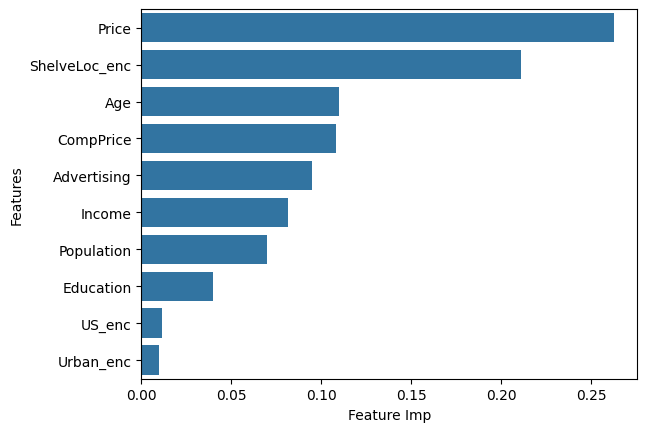

In [20]:
import seaborn as sns
sns.barplot(x = df['Feature Imp'], y = df['Features'])
plt.show() 

In [21]:
# Measures drop in performance (increase in MSE) when a feature has its rows shuffled so that it becomes meaningless to
# the target variable.

from sklearn.inspection import permutation_importance
result = permutation_importance(bag,
                                x_train, y_train,
                                scoring = 'neg_mean_squared_error',
                                n_repeats = 10,
                                random_state = 0)
result.importances_mean

array([1.15308956, 0.64163301, 1.06315083, 0.36520851, 4.39963819,
       1.20591378, 0.19625118, 3.76168445, 0.05206333, 0.08095336])

In [22]:
df1 = pd.DataFrame({'Features': x_train.columns, 'Feature_Importance':result.importances_mean})
df1 = df1.sort_values(ascending=False, by = 'Feature_Importance')
df1.head()

,Features,Feature_Importance
4,Price,4.399638
7,ShelveLoc_enc,3.761684
5,Age,1.205914
0,CompPrice,1.153090
2,Advertising,1.063151


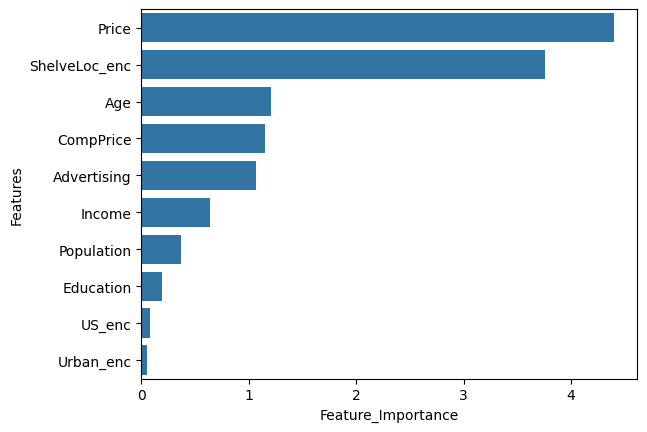

In [23]:
sns.barplot(x = df1['Feature_Importance'], y = df1['Features'])
plt.show()

In [24]:
# OOB

oob_bag = RandomForestRegressor(n_estimators=800, max_features=int(np.ceil(n_features/3)), random_state=0, oob_score = True)
oob_bag.fit(x_train, y_train)

,n_estimators,800
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [25]:
# oob r2 score
oob_bag.oob_score_

0.6545228720197391

In [26]:
# oob mse
y_pred_oob = oob_bag.oob_prediction_
mean_squared_error(y_train, y_pred_oob)

2.7678686179925154